# Ploting functions 
Data ploting fuctions

In [3]:
from locale import normalize

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import warnings

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [24]:
# Plotting functions
def plot_protein_phosphosites_together(df , proteins= list, legend = list, path= str, saving_path = str,
                              saving_info = "", save_pdf = False, save_png = False, plot_close = False, fit_y_lims = False):
    '''Plot to PDF ALL phosphosites of a protein together in one single plot. "y" limits are ajusted to the limits of each phosphosites'''
    for protein in proteins:

        # Create sub-dataframe with only the protein we are interested in. If the protein doesn't exist in the dataframe skip code
        if protein in df['prot_name'].to_list():
            sub_df = df.loc[df['prot_name'] == protein].copy()
            print(f"Ploting sites of protein {protein}")
        elif protein in df['protein_ID'].to_list():
            sub_df = df.loc[df['protein_ID'] == protein].copy()
            print(f"Ploting sites of protein {protein}")
        else:
            print(f"The protein {protein} is not present in the dataset")
            continue
        #Check if a folder for the desired protein exists. If no, create one
        to_save = re.sub("Data.*", saving_path, path)
        if protein in os.listdir(to_save):
            pass
        else:
            path = f"{to_save}/{protein}"
            os.makedirs(path)
        
        sub_df.sort_values(by=['site'], inplace=True)
    
        # Geting some basic information and parameters for the plots
        number_phos = len(sub_df)
        sqrt_n_p = int(np.ceil(np.sqrt(number_phos)))
        empty_plots = (sqrt_n_p * sqrt_n_p) - number_phos
        
        # If the protein only has one phosphosite the code cannot make a plot with one subplot, so I'll have to make it individually
        single_phsite_proteins = []
        if number_phos == 1:
            single_phsite_proteins.append(protein)
            print(f"Protein {protein} has only one phosphosite. Plot it individually")
            continue
            
        # Avoid getting rows with empty plots
        if empty_plots >= sqrt_n_p: 
            sqrt_n_p_X = sqrt_n_p - 1
        else:
            sqrt_n_p_X = sqrt_n_p

        # Decide wether to fit the y axes or not
        if fit_y_lims == True: #Fit "y" limits for each phosphosite
            y_fixed = "_y_axis_fixed"
        elif type(fit_y_lims) == list:
            y_lim_min = fit_y_lims[0]
            y_lim_max = fit_y_lims[1]
            y_fixed = f"_y_axis_fixed_{y_lim_min}_{y_lim_max}"
        else: # Fit the same "y" limit for all phosphosites
            sub_values_df = sub_df.iloc[:,3:]
            y_lim_max = (sub_values_df.max().max())*1.1
            y_lim_min = (sub_values_df.min().min())*1.1
            y_fixed = "_y_axis_general"
        
        k = 0 # Counter to stop ploting when there is no more phosphosites
        
        # Seting subplots aprameters
        fig, ax = plt.subplots(sqrt_n_p,sqrt_n_p_X, figsize=(18, 13)) #figsize=(7, 4) figsize=(18, 13) figsize=(29.7, 21)
        fig.tight_layout(w_pad = 1.75, h_pad = 3)
        plt.subplots_adjust(top=0.94) #percentage of the figure that the plots are using
        
        # Go through the sub_df to plot all the phosphosites
        for i in range(sqrt_n_p): #y
            for j in range(sqrt_n_p_X): #X
                if k == number_phos: # Stop plotting, all phosphorylation sites have been plotted
                    continue
                else:
                    # IN THIS CASE I AM ACCESSING THE ROW BY INDEXING, 
                    # that's why the "id" is alreay at possition 0 and all the indexing is shifted compared to the datafram by -1
                    row = sub_df.iloc[k,:] # Go through the rows of the subdataset with the phsophosites for the protein
        # Collect identification data of the phosphorylatio site
                    site = row[2]
                    name = row[1]
                    id = row[0]

        # Collect data of the time points of the phosphosites
                    all_times = row[3:24]
                    EGF = row[3:10]
                    INS = row[10:17]
                    EGFnINS = row[17:24]
            
                    groups = [EGF, INS, EGFnINS]
                    colors = ['r', 'b', 'fuchsia']
                    
        # Collect data of the standard deviation of each timepoint 
                    EGF_sd = row[26:33]
                    INS_sd = row[33:40]
                    EGFnINS_sd = row[40:]
                    groups_sd = [EGF_sd, INS_sd, EGFnINS_sd]
        # Collect data about number of replicates in which the phosphosite was detected
                    n_rep = row[24]
                    
        # Start plotting
                    for c in range(3):
                        if n_rep == 1:
                            al = 0.3
                        else:
                            al = 1
                        ax[i,j].errorbar(x =[ 'Full','0','1','2','5','10','90'], y = groups[c], yerr=groups_sd[c], marker='o', color=colors[c], alpha = al, capsize= 4, elinewidth = 1.3)  
    
        # Subplot parameters
                    ax[i,j].set_title(f"{str(re.findall(r'^.*~', site))[2:-3]}_n_reps{n_rep}") # , weight='bold'  INCLUDE THE POSIBILITY OF ADDING THE PHOSPHOSITE SEQUENCE
                    ax[i,j].set_xlabel("Time (min)")
                    ax[i,j].set_ylabel("Log2FC")
                    ax[i,j].grid()
    
        # Using specific limits
                    if fit_y_lims == True: 
                        ax[i,j].set_ylim(min(all_times)*1.1-0.1, max(all_times)*1.1+0.1)
                    else: # Using general limits
                        ax[i,j].set_ylim(y_lim_min, y_lim_max)
                    ax[i,j].set_xlim(-1, 7)
            
        # count the phosphorylation site as plotted
                    k = k + 1
    
        # General parameters of the plot
        fig.legend(labels=legend, loc="upper right", ncol=len(groups))
        fig.suptitle(f"{name}_{id}", weight='bold')
        
        # Saving the plot
        if save_pdf == True:
            plt.savefig(f"{to_save}/{protein}/{name}_{id}_0_All{y_fixed}{saving_info}.pdf")
            print(f"{protein} Plot saved as PDF")
        else: 
            print(f"{protein} Plot not saved")
        if save_png == True:
            plt.savefig(f"{to_save}/{protein}/{name}_{id}_0_All{y_fixed}{saving_info}.png")
            print(f"{protein} Plot saved as PNG")
        if plot_close == True:
            plt.close()
    
def plot_protein_phosphosites_individually(df , proteins= list, legend = list, path= str, saving_path = str,
                              saving_info = "", save_pdf = False, save_png = False, plot_close = False, fit_y_lims = True):
    '''Create a PDF for each phosphorylation sites of a protein'''
    
    for protein in proteins:
        
        #Create sub-dataframe with only the protein we are interested in. If the protein doesn't exist in the dataframe skip code
        if protein in df['prot_name'].to_list():
            sub_df = df.loc[df['prot_name'] == protein].copy()
            print(f"Ploting sites of protein {protein}")
        elif protein in df['protein_ID'].to_list():
            sub_df = df.loc[df['protein_ID'] == protein].copy()
            print(f"Ploting sites of protein {protein}")
        else:
            print(f"The protein {protein} is not present in the dataset")
            continue
        #Check if a folder for the desired protein exists. If no, create one
        to_save = re.sub("Data.*", saving_path, path)
        if protein in os.listdir(to_save):
            pass
        else:
            path = f"{to_save}/{protein}"
            os.makedirs(path)
            
        for row in sub_df.itertuples():
            # HERE THE ROW IS TAKEN OUT OF THE SUBDATAFRAME. 
            # This is why position "0" is not usefull, is just the index in the dataframe
            site = row[3]
            name = row[2]
            id = row[1]
    
            all_times = row[4:25]
            EGF = row[4:11]
            INS = row[11:18]
            EGFnINS = row[18:25]
            groups = [EGF, INS, EGFnINS]
            
            # Collect data of the standard deviation of each timepoint 
            EGF_sd = row[27:34]
            INS_sd = row[34:41]
            EGFnINS_sd = row[41:]
            groups_sd = [EGF_sd, INS_sd, EGFnINS_sd]
                    
    # Collect data about number of replicates in which the phosphosite was detected
            n_rep = row[25]
                                 
            colors = ['r', 'b', 'fuchsia']
    
            fig, ax = plt.subplots(figsize=(7, 4))
    
            for c in range(3):
                if n_rep == 1:
                    al = 0.3
                else:
                    al = 1
                ax.errorbar(x =['Full','0','1','2','5','10','90'], y = groups[c], yerr=groups_sd[c], marker='o', color=colors[c], label=legend[c], capsize= 4, elinewidth = 1.3, alpha = al)
                
            ax.set_title(f"{name}_{site}_n_rep{n_rep}")
            ax.set_xlabel("Time (min)")
            ax.set_ylabel("Log2FC")
            ax.set_xlim(-1, 7)
            if fit_y_lims == True:
                ax.set_ylim(min(all_times)*1.1-0.1, max(all_times)*1.1+0.1)
                y_lim = ""
            elif type(fit_y_lims) == list:
                ax.set_ylim(fit_y_lims[0], fit_y_lims[1])
                y_lim = f"_y_axis_fixed_{fit_y_lims[0]}_{fit_y_lims[1]}"
    
            ax.legend()
            ax.grid()
            
            if save_pdf == True:
                plt.savefig(f"{to_save}/{protein}/{name}_{site}{y_lim}{saving_info}.pdf")
                print(f"{site} Plot saved as PDF")
            else: 
                print(f"{site} Plot not saved")
            if save_png == True:
                plt.savefig(f"{to_save}/{protein}/{name}_{site}{y_lim}{saving_info}.png")
                print(f"{site} Plot saved as PNG")
            if plot_close == True:
                plt.close()
                
def plot_dataset_phosphosites_together(df , proteins= list, legend = list, path= str, saving_path = str, dataset_folder = str, dataset_name = str, 
                                 saving_info = "", save_pdf = False, save_png = False, plot_close = False, fit_y_lims = True):
    '''Plot all the phosphorilation sites of a dataset'''
    
    #Check if a folder for the desired protein exists. If no, create one 
    to_save = re.sub("Data.*", saving_path, path)
    if dataset_name in os.listdir(to_save):
        pass
    else:
        path = f"{to_save}/{dataset_name}"
        os.makedirs(path)
    
    #Geting some basic information and parameters for the plots
    number_phos = len(df)
    sqrt_n_p = int(np.ceil(np.sqrt(number_phos)))
    empty_plots = (sqrt_n_p * sqrt_n_p) - number_phos
    
    # Avoid getting rows with empty plots
    if empty_plots >= sqrt_n_p:
        sqrt_n_p_X = sqrt_n_p - 1
    else:
        sqrt_n_p_X = sqrt_n_p
    
    # Decide wether to fit the y axes or not
    if fit_y_lims == True: #Fit "y" limits for each phosphosite
        y_fixed = "_y_axis_fixed"
    elif type(fit_y_lims) == list:
        y_lim_max = fit_y_lims[1]
        y_lim_min = fit_y_lims[0]
        y_fixed = f"_y_axis_fixed_{y_lim_min}_{y_lim_max}"
    else: # Fit the same "y" limit for all phosphosites
        sub_values_df = df.iloc[:,3:47]
        y_lim_max = (sub_values_df.max().max())*1.1
        y_lim_min = (sub_values_df.min().min())*1.1
        y_fixed = "_Y_fixed_general"
        
    k = 0 # Counter to stop ploting when there is no more phosphosites
    # Seting subplots parameters
    fig, ax = plt.subplots(sqrt_n_p,sqrt_n_p_X, figsize=(18, 13)) #figsize=(7, 4) figsize=(18, 13) figsize=(29.7, 21)
    fig.tight_layout(w_pad = 1.75, h_pad = 3)
    plt.subplots_adjust(top=0.94) #percentage of the figure that the plots are using
    
    # Go through the sub_df to plot all the phosphosites
    for i in range(sqrt_n_p): #y
        for j in range(sqrt_n_p_X): #X
            if k == number_phos: # Stop plotting, all phosphorylation sites have been plotted
                continue
            else:
                row = df.iloc[k,:] # Go through the rows of the subdataset with the phsophosites for the protein
    # Collect identification data of the phosphorylatio site
                site = row[2]
                name = row[1]
                id = row[0]
    # Collect data of the time points of the phosphosites
                all_times = row[3:24]
                EGF = row[3:10]
                INS = row[10:17]
                EGFnINS = row[17:24]
    
                groups = [EGF, INS, EGFnINS]
                colors = ['r', 'b', 'fuchsia']
    
    # Collect data of the standard deviation of each timepoint

                EGF_sd = row[26:33]
                INS_sd = row[33:40]
                EGFnINS_sd = row[40:47]
                groups_sd = [EGF_sd, INS_sd, EGFnINS_sd]
                #print(groups, groups_sd)
    # Collect data about number of replicates in which the phosphosite was detected
                n_rep = row[24]
    
    # Start plotting
                for c in range(3):
                    if n_rep == 1:
                        al = 0.3
                    else:
                        al = 1
                    ax[i,j].errorbar(x =[ 'Full','0','1','2','5','10','90'], y = groups[c], yerr=groups_sd[c], marker='o', color=colors[c], alpha = al, capsize= 4, elinewidth = 1.3)
    
    # Subplot parameters
                ax[i,j].set_title(f"{str(re.findall(r'^.*~', site))[2:-3]}_n_reps{n_rep}") # , weight='bold'  INCLUDE THE POSIBILITY OF ADDING THE PHOSPHOSITE SEQUENCE
                ax[i,j].set_xlabel("Time (min)")
                ax[i,j].set_ylabel("Log2FC")
                ax[i,j].grid()
    # Using specific limits
                if fit_y_lims == True:
                    ax[i,j].set_ylim(min(all_times)*1.1-0.1, max(all_times)*1.1+0.1)
                else: # Using general limits
                    ax[i,j].set_ylim(y_lim_min, y_lim_max)
                ax[i,j].set_xlim(-1, 7)
    
    # count the phosphorylation site as plotted
                k = k + 1
    # General parameters of the plot
    fig.legend(labels=legend, loc="upper right", ncol=len(groups))
    fig.suptitle(f"{dataset_name}", weight='bold')
    
    # Saving the plot
    if save_pdf == True:
        plt.savefig(f"{to_save}/{dataset_folder}/{dataset_name}_All{y_fixed}{saving_info}.pdf")
        print(f"{dataset_name} Plot saved as PDF")
    else:
        print(f"{dataset_name} Plot not saved")
    if save_png == True:
        plt.savefig(f"{to_save}/{dataset_folder}/{dataset_name}_All{y_fixed}{saving_info}.png")
        print(f"{dataset_name} Plot saved as PNG")
    if plot_close == True:
        plt.close()


In [26]:
# Load the dataframe independently so it has not to be loaded each time we want to plot a set of proteins
# "Experiment/1_hTERT_HME1/Data/Processed/full_starve_continuous_FC_nrep_SD.xlsx"
# "Experiment/1_hTERT_HME1/Data/Processed/full_starve_continuous_normalized_nrep_SD.xlsx"
full_df = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/full_starve_continuous_FC_nrep_SD.xlsx")

["Q9H8S9", "Q7L9L4", "Q70IA8", "P46937", "Q16635", "O00750", "Q13043", "Q10325", "O54748", "O95835", "Q9NRM7"]

Ploting sites of protein EGFR
EGFR Plot saved as PDF


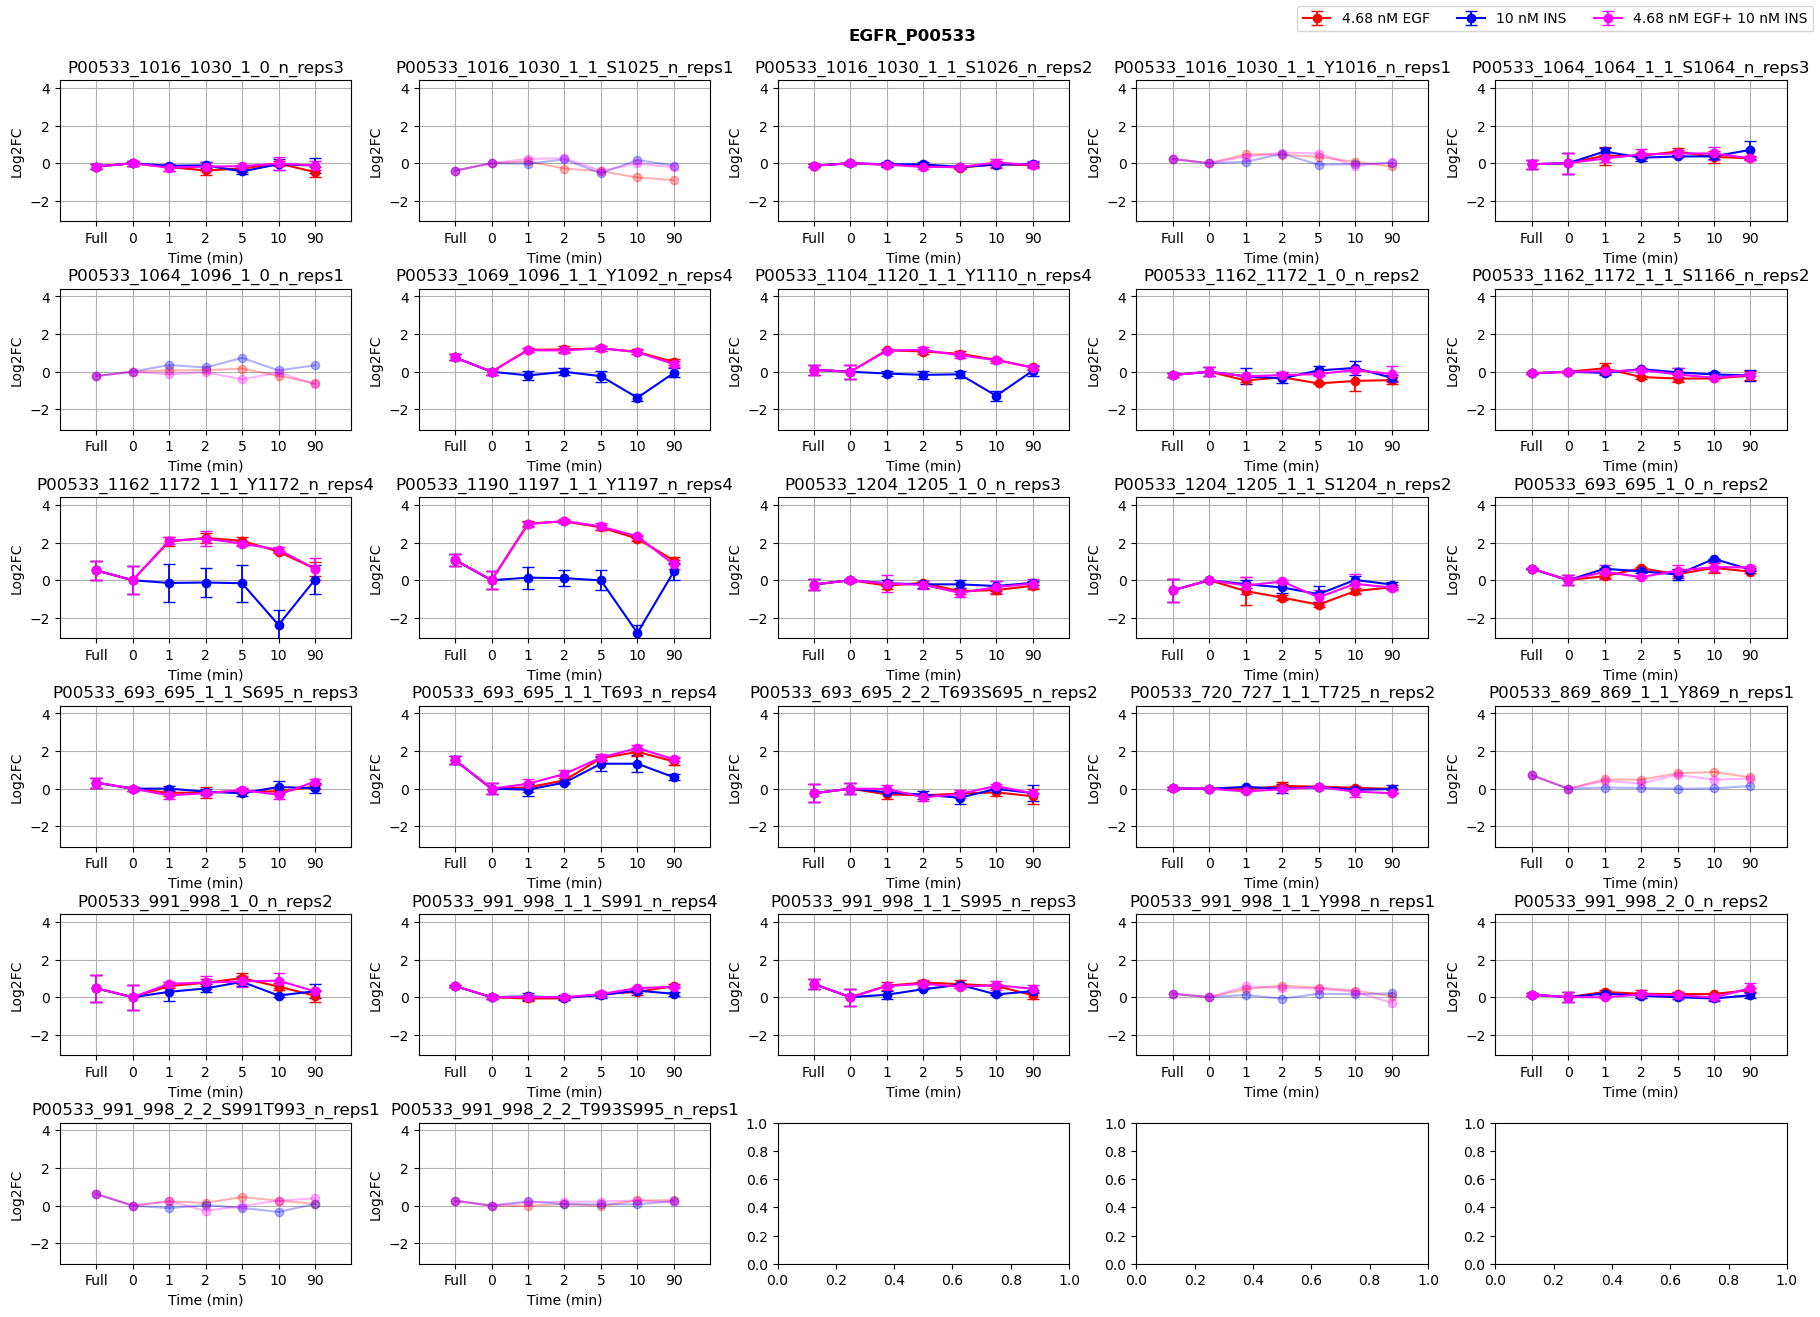

In [28]:
warnings.filterwarnings('ignore')

plot_protein_phosphosites_together(df= full_df, proteins= ["EGFR"], 
                                   legend = ['4.68 nM EGF', '10 nM INS', '4.68 nM EGF+ 10 nM INS'], 
                                   path= "Experiment/1_hTERT_HME1/Data/Processed/full_starve_continuous_FC_nrep_SD.xlsx", 
                                   saving_path = "Results/Interesting_proteins",
                                   saving_info = "FC", save_pdf = True,
                                   save_png = False, plot_close = False, fit_y_lims = False)

# plot_protein_phosphosites_individually(df= full_df, proteins= ["Q70IA8"], 
#                                        legend = ['4.68 nM EGF', '10 nM INS', '4.68 nM EGF+ 10 nM INS'], 
#                                        path= "Experiment/1_hTERT_HME1/Data/Processed/full_starve_continuous_FC_nrep_SD.xlsx", saving_path = "Results/Interesting_proteins",
#                                        saving_info = "", save_pdf = False,
#                                        save_png = False, plot_close = False, fit_y_lims = True)

# plot_dataset_phosphosites_together(df= , legend = ['4.68 nM EGF', '10 nM INS', '4.68 nM EGF+ 10 nM INS'], 
#                                    path= "Experiment/1_hTERT_HME1/Data/Processed/full_starve_continuous_FC_nrep_SD.xlsx", saving_path = "Results/Sub_datasets",
#                                    dataset_folder = "Testing", dataset_name = "Testing", 
#                                    saving_info = "", save_pdf = False, save_png = False, plot_close = True, fit_y_lims = False)

In [22]:
normalized = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/full_starve_continuous_normalized_nrep_SD.xlsx")
normalized.loc[normalized["prot_name"] == "EGFR"]

,protein_ID,prot_name,site,mean_EGF_full,mean_EGF_starve,mean_EGF1,mean_EGF2,mean_EGF5,mean_EGF10,mean_EGF90,...,sd_INS5,sd_INS10,sd_INS90,sd_EGFnINS_full,sd_EGFnINS_starve,sd_EGFnINS1,sd_EGFnINS2,sd_EGFnINS5,sd_EGFnINS10,sd_EGFnINS90
3891,P00533,EGFR,P00533_1016_1030_1_0~ALMDEEDMDDVVDADEYLIPQQGFF...,13.387428,13.562009,13.355817,13.180784,13.278225,13.548667,13.092929,...,0.118176,0.288798,0.399052,0.129052,0.138684,0.190731,0.220361,0.032003,0.331210,0.220324
3892,P00533,EGFR,P00533_1016_1030_1_1_S1025~ALMDEEDMDDVVDADEYLI...,10.913901,11.305811,11.400161,11.022983,10.880980,10.554166,10.404976,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3893,P00533,EGFR,P00533_1016_1030_1_1_S1026~ALMDEEDMDDVVDADEYLI...,13.556378,13.685158,13.604230,13.572543,13.445974,13.636550,13.575348,...,0.034710,0.042453,0.102275,0.064125,0.084509,0.071432,0.105405,0.082078,0.211930,0.184082
3894,P00533,EGFR,P00533_1016_1030_1_1_Y1016~ALMDEEDMDDVVDADEyLI...,11.487675,11.262934,11.739201,11.717429,11.603425,11.335568,11.090889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3895,P00533,EGFR,P00533_1064_1064_1_1_S1064~EDsFLQR,13.300967,13.351819,13.751803,13.748264,13.973259,13.690415,13.614123,...,0.055233,0.126737,0.486741,0.240808,0.556326,0.174512,0.266897,0.185063,0.321290,0.073367
3896,P00533,EGFR,P00533_1064_1096_1_0~EDSFLQRYSSDPTGALTEDSIDDTF...,12.097538,12.324958,12.394276,12.404356,12.491553,12.110114,11.707815,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3897,P00533,EGFR,P00533_1069_1096_1_1_Y1092~YSSDPTGALTEDSIDDTFL...,14.664673,13.907842,15.070546,15.091686,15.148966,14.961854,14.423300,...,0.283902,0.182445,0.239229,0.159524,0.151752,0.098687,0.142869,0.121943,0.120385,0.158456
3898,P00533,EGFR,P00533_1104_1120_1_1_Y1110~RPAGSVQNPVyHNQPLNPAPSR,16.803116,16.703378,17.847661,17.777984,17.656308,17.337138,16.928513,...,0.196412,0.253482,0.252535,0.251225,0.377649,0.057100,0.130064,0.129726,0.126547,0.125669
3899,P00533,EGFR,P00533_1162_1172_1_0~GSHQISLDNPDYQQDFFPK,11.998208,12.171797,11.709074,11.875319,11.550296,11.683376,11.727009,...,0.259396,0.369812,0.161139,0.104553,0.225783,0.046956,0.142481,0.115720,0.032436,0.401720
3900,P00533,EGFR,P00533_1162_1172_1_1_S1166~GSHQIsLDNPDYQQDFFPK,12.778170,12.864918,13.046781,12.582886,12.501410,12.505956,12.658088,...,0.241026,0.120400,0.282372,0.056026,0.043509,0.073305,0.104132,0.352511,0.005140,0.081968


In [23]:
fc = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/full_starve_continuous_FC_nrep_SD.xlsx")
fc.loc[fc["prot_name"] == "EGFR"]

,protein_ID,prot_name,site,EGF_full,EGF_starve,EGF_1,EGF_2,EGF_5,EGF_10,EGF_90,...,sd_INS5,sd_INS10,sd_INS90,sd_full_EGFnINS,sd_starve_EGFnINS,sd_EGFnINS1,sd_EGFnINS2,sd_EGFnINS5,sd_EGFnINS10,sd_EGFnINS90
3891,P00533,EGFR,P00533_1016_1030_1_0~ALMDEEDMDDVVDADEYLIPQQGFF...,-0.174581,0,-0.206192,-0.381225,-0.283784,-0.013343,-0.469080,...,0.118176,0.288798,0.399052,0.129052,0.138684,0.190731,0.220361,0.032003,0.331210,0.220324
3892,P00533,EGFR,P00533_1016_1030_1_1_S1026~ALMDEEDMDDVVDADEYLI...,-0.128780,0,-0.080928,-0.112616,-0.239184,-0.048609,-0.109810,...,0.034710,0.042453,0.102275,0.064125,0.084509,0.071432,0.105405,0.082078,0.211930,0.184082
3893,P00533,EGFR,P00533_1064_1064_1_1_S1064~EDsFLQR,-0.050852,0,0.399983,0.396444,0.621440,0.338595,0.262304,...,0.055233,0.126737,0.486741,0.240808,0.556326,0.174512,0.266897,0.185063,0.321290,0.073367
3894,P00533,EGFR,P00533_1069_1096_1_1_Y1092~YSSDPTGALTEDSIDDTFL...,0.756831,0,1.162704,1.183844,1.241124,1.054011,0.515458,...,0.283902,0.182445,0.239229,0.159524,0.151752,0.098687,0.142869,0.121943,0.120385,0.158456
3895,P00533,EGFR,P00533_1104_1120_1_1_Y1110~RPAGSVQNPVyHNQPLNPAPSR,0.099738,0,1.144283,1.074607,0.952930,0.633760,0.225135,...,0.196412,0.253482,0.252535,0.251225,0.377649,0.057100,0.130064,0.129726,0.126547,0.125669
3896,P00533,EGFR,P00533_1162_1172_1_0~GSHQISLDNPDYQQDFFPK,-0.173589,0,-0.462723,-0.296477,-0.621500,-0.488420,-0.444787,...,0.259396,0.369812,0.161139,0.104553,0.225783,0.046956,0.142481,0.115720,0.032436,0.401720
3897,P00533,EGFR,P00533_1162_1172_1_1_Y1172~GSHQISLDNPDyQQDFFPK,0.519884,0,2.061595,2.247874,2.091043,1.518598,0.610951,...,0.976338,0.805203,0.757576,0.492461,0.741661,0.181604,0.377512,0.142591,0.112966,0.569444
3898,P00533,EGFR,P00533_1190_1197_1_1_Y1197~GSTAENAEyLR,1.069837,0,3.007948,3.125776,2.810113,2.206917,1.044069,...,0.530484,0.415178,0.426553,0.315827,0.467362,0.127321,0.102320,0.179547,0.074434,0.258236
3899,P00533,EGFR,P00533_1204_1205_1_1_S1204~VAPQsSEFIGA,-0.537459,0,-0.578195,-0.925529,-1.299026,-0.578415,-0.376915,...,0.405770,0.192961,0.113903,0.610887,0.017640,0.449936,0.067246,0.388656,0.515953,0.131690
3900,P00533,EGFR,P00533_693_695_1_1_S695~ELVEPLTPsGEAPNQALLR,0.320507,0,-0.223284,-0.205531,-0.121656,-0.152726,0.107387,...,0.150052,0.302182,0.268773,0.261008,0.103815,0.172348,0.121673,0.105933,0.216348,0.111940
